**Цель:**
1. Изучить структуру датасета
2. Проверить баланс классов
3. Найти визуальные закономерности
4. Обосновать выбор признаков

In [4]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path().resolve().parent / 'src'))
from preprocessing import load_data

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [5]:
df = load_data()
df.head()

,GenHlth,BMI,Age,HighBP,PhysActivity,HeartDiseaseorAttack,DiffWalk,Diabetes_binary
0,3.0,26.0,4.0,1.0,1.0,0.0,0.0,0.0
1,3.0,26.0,12.0,1.0,0.0,0.0,0.0,0.0
2,1.0,26.0,13.0,0.0,1.0,0.0,0.0,0.0
3,3.0,28.0,11.0,1.0,1.0,0.0,0.0,0.0
4,2.0,29.0,8.0,0.0,1.0,0.0,0.0,0.0


In [6]:
df.shape

(70692, 8)

In [7]:
df["Diabetes_binary"].value_counts()

Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64

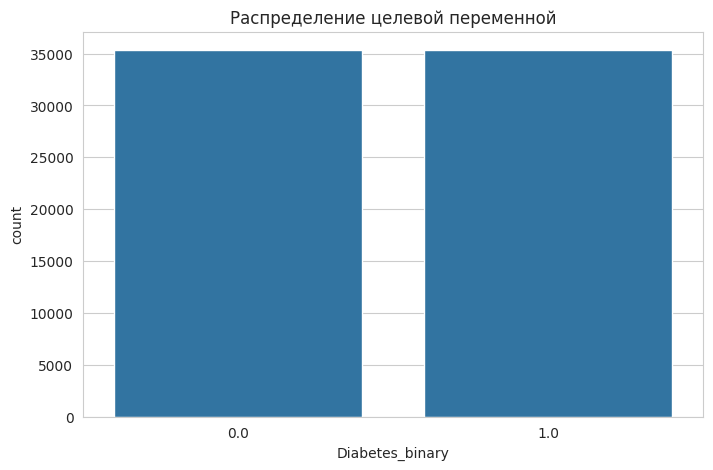

In [8]:
sns.countplot(data=df, x="Diabetes_binary")
plt.title("Распределение целевой переменной")
plt.show()

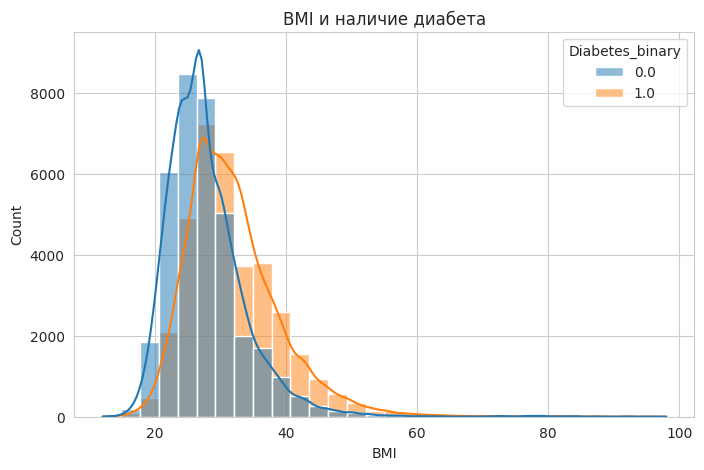

In [9]:
sns.histplot(data=df, x="BMI", hue="Diabetes_binary", kde=True, bins=30)
plt.title("BMI и наличие диабета")
plt.show()

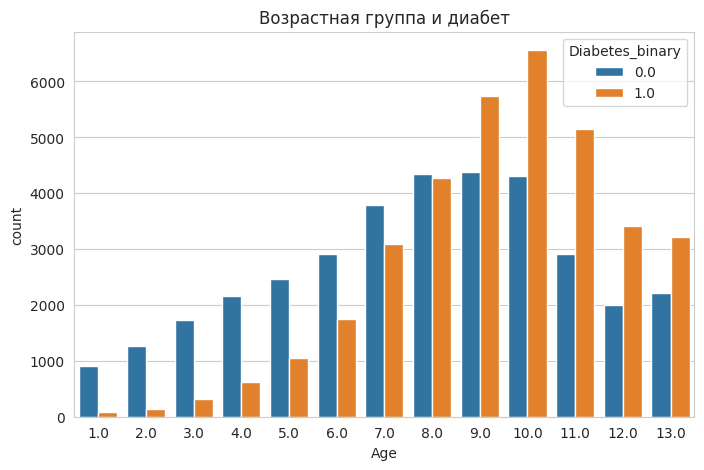

In [10]:
sns.countplot(data=df, x="Age", hue="Diabetes_binary")
plt.title("Возрастная группа и диабет")
plt.show()

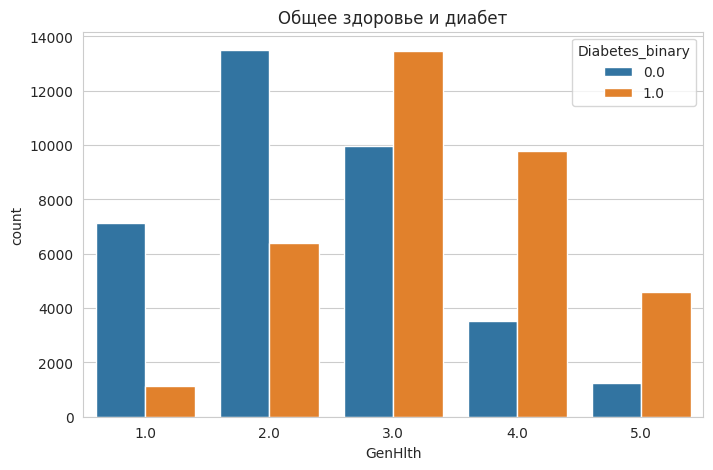

In [11]:
sns.countplot(data=df, x="GenHlth", hue="Diabetes_binary")
plt.title("Общее здоровье и диабет")
plt.show()

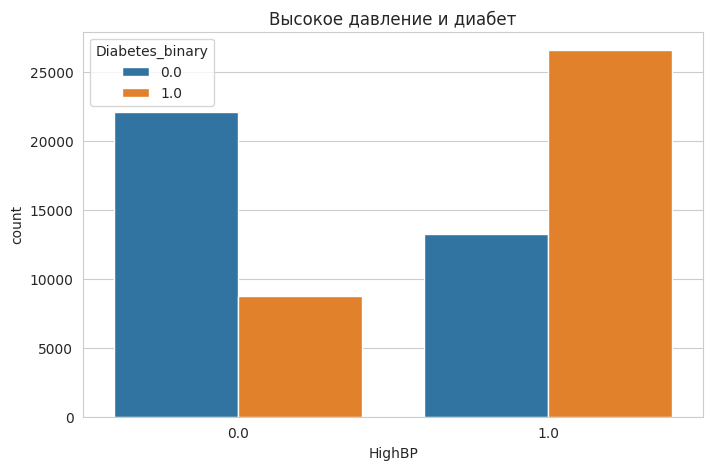

In [12]:
sns.countplot(data=df, x="HighBP", hue="Diabetes_binary")
plt.title("Высокое давление и диабет")
plt.show()

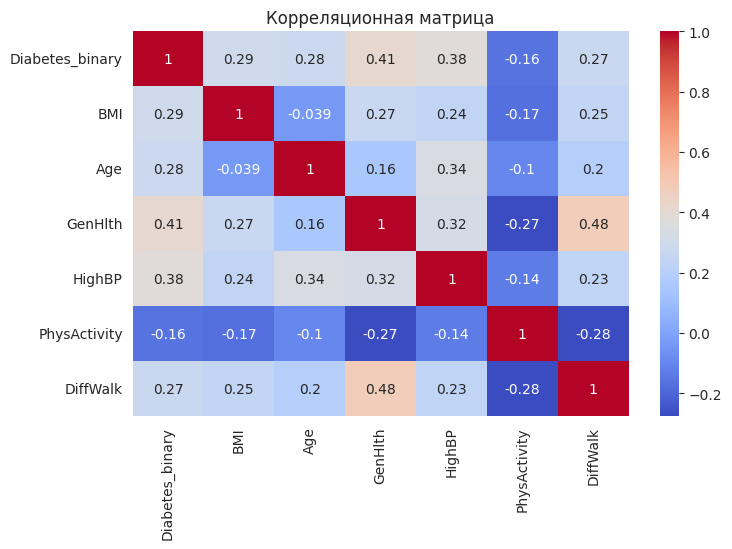

In [13]:
corr = df[[
    "Diabetes_binary",
    "BMI",
    "Age",
    "GenHlth",
    "HighBP",
    "PhysActivity",
    "DiffWalk"
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Корреляционная матрица")
plt.show()

**Выводы:**

1. Датасет сбалансирован.
2. BMI выше у пациентов с диабетом.
3. Возраст связан с ростом риска.
4. Плохое состояние здоровья связано с диабетом.
5. Высокое давление является сильным фактором риска.